# Target Pipeline Insights

Run the data pipeline first so the files under `output/` exist, then run this notebook top to bottom to generate local charts.

In [17]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
OUTPUT_DIR = PROJECT_ROOT / "output"
INSIGHTS_PATH = OUTPUT_DIR / "insights.json"
CLEANED_DATA_PATH = OUTPUT_DIR / "cleaned__target_data.csv"
CITY_REPORT_DIR = OUTPUT_DIR / "sales_by_city_report"

if not INSIGHTS_PATH.exists() or not CLEANED_DATA_PATH.exists():
    raise FileNotFoundError("Run the pipeline first so output/insights.json and output/cleaned__target_data.csv exist.")

with INSIGHTS_PATH.open("r", encoding="utf-8") as file:
    insights = json.load(file)

cleaned_df = pd.read_csv(CLEANED_DATA_PATH)
city_report_paths = sorted(CITY_REPORT_DIR.glob("part-*.csv"))
city_report_df = pd.read_csv(city_report_paths[0]) if city_report_paths else pd.DataFrame()

print(f"Loaded {len(cleaned_df)} cleaned rows")
print(f"Insights keys: {', '.join(sorted(insights.keys()))}")

Loaded 978 cleaned rows
Insights keys: average_approval_delay_hours, average_delivery_time_days, average_freight_value, average_review_score, average_total_order_value, order_status_distribution, review_to_delivery_correlation, row_count, sales_by_city, sales_by_state


In [18]:
summary_df = pd.DataFrame(
    {
        "metric": [
            "row_count",
            "average_total_order_value",
            "average_freight_value",
            "average_delivery_time_days",
            "average_approval_delay_hours",
            "average_review_score",
            "review_to_delivery_correlation",
        ],
        "value": [
            insights["row_count"],
            insights["average_total_order_value"],
            insights["average_freight_value"],
            insights["average_delivery_time_days"],
            insights["average_approval_delay_hours"],
            insights["average_review_score"],
            insights["review_to_delivery_correlation"],
        ],
    }
)

summary_df

,metric,value
0,row_count,978.0000
1,average_total_order_value,149.2500
2,average_freight_value,21.4100
3,average_delivery_time_days,12.3300
4,average_approval_delay_hours,10.4100
5,average_review_score,4.0900
6,review_to_delivery_correlation,0.0218


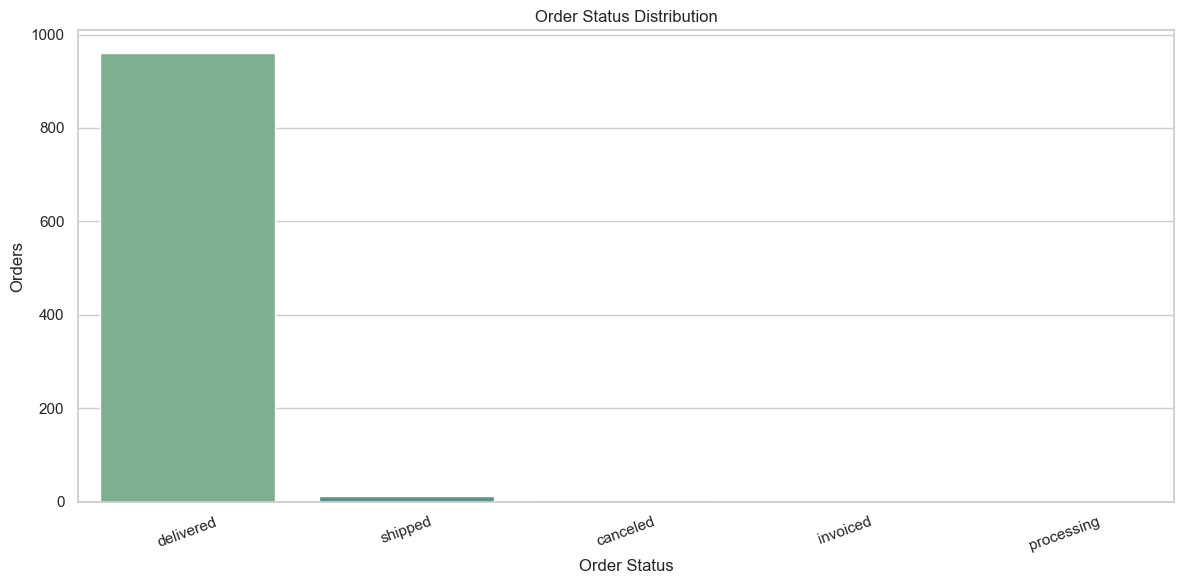

In [19]:
status_df = (
    pd.Series(insights["order_status_distribution"], name="orders")
    .sort_values(ascending=False)
    .rename_axis("order_status")
    .reset_index()
)

plt.figure()
sns.barplot(data=status_df, x="order_status", y="orders", hue="order_status", dodge=False, palette="crest", legend=False)
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Orders")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

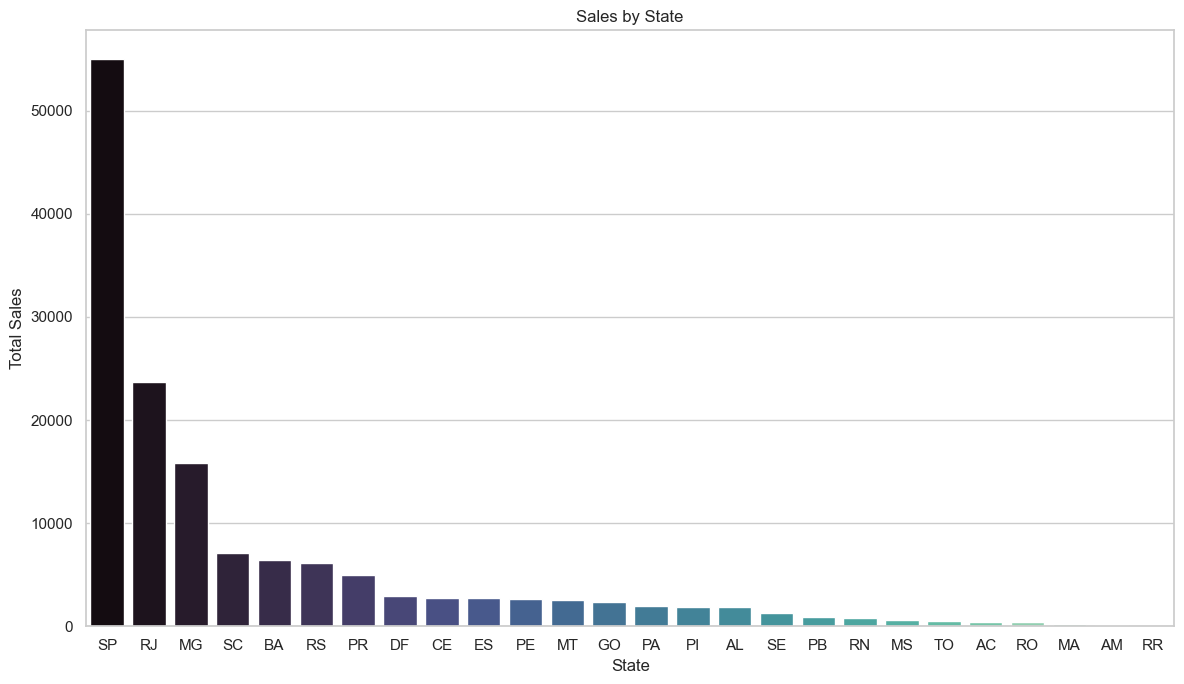

In [20]:
state_df = (
    pd.Series(insights["sales_by_state"], name="total_sales")
    .sort_values(ascending=False)
    .rename_axis("customer_state")
    .reset_index()
)

plt.figure(figsize=(12, 7))
sns.barplot(data=state_df, x="customer_state", y="total_sales", hue="customer_state", dodge=False, palette="mako", legend=False)
plt.title("Sales by State")
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

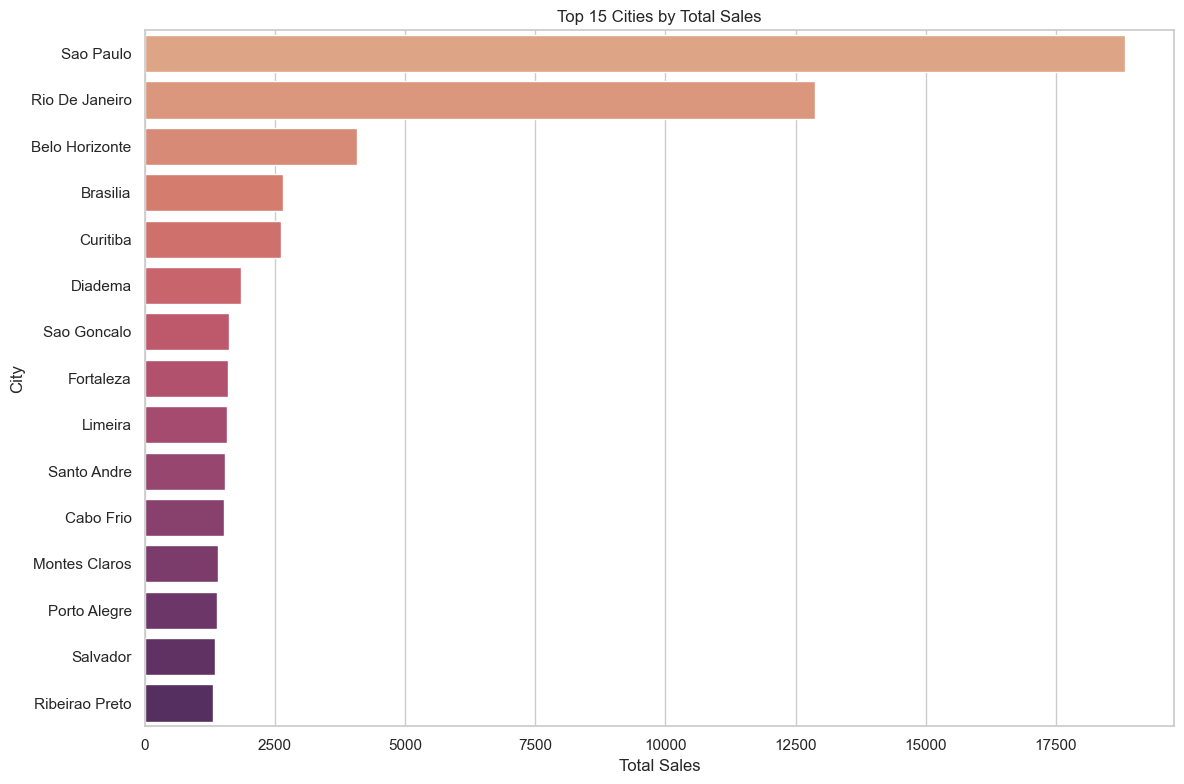

In [22]:
top_city_df = (
    pd.Series(insights["sales_by_city"], name="total_sales")
    .sort_values(ascending=False)
    .head(15)
    .rename_axis("customer_city")
    .reset_index()
)

plt.figure(figsize=(12, 8))
sns.barplot(data=top_city_df, x="total_sales", y="customer_city", hue="customer_city", dodge=False, palette="flare", legend=False)
plt.title("Top 15 Cities by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("City")
plt.tight_layout()
plt.show()

In [23]:
yearly_products_df = cleaned_df.copy()
yearly_products_df["order_purchase_timestamp"] = pd.to_datetime(
    yearly_products_df["order_purchase_timestamp"], errors="coerce"
)
yearly_products_df["order_items_qty"] = pd.to_numeric(
    yearly_products_df["order_items_qty"], errors="coerce"
)
yearly_products_df = yearly_products_df.dropna(
    subset=["order_purchase_timestamp", "order_items_qty"]
)

products_per_year_df = (
    yearly_products_df.assign(
        order_year=yearly_products_df["order_purchase_timestamp"].dt.year
    )
    .groupby("order_year", as_index=False)["order_items_qty"]
    .sum()
    .sort_values("order_year")
)

products_per_year_df

,order_year,order_items_qty
0,2016,2
1,2017,498
2,2018,567


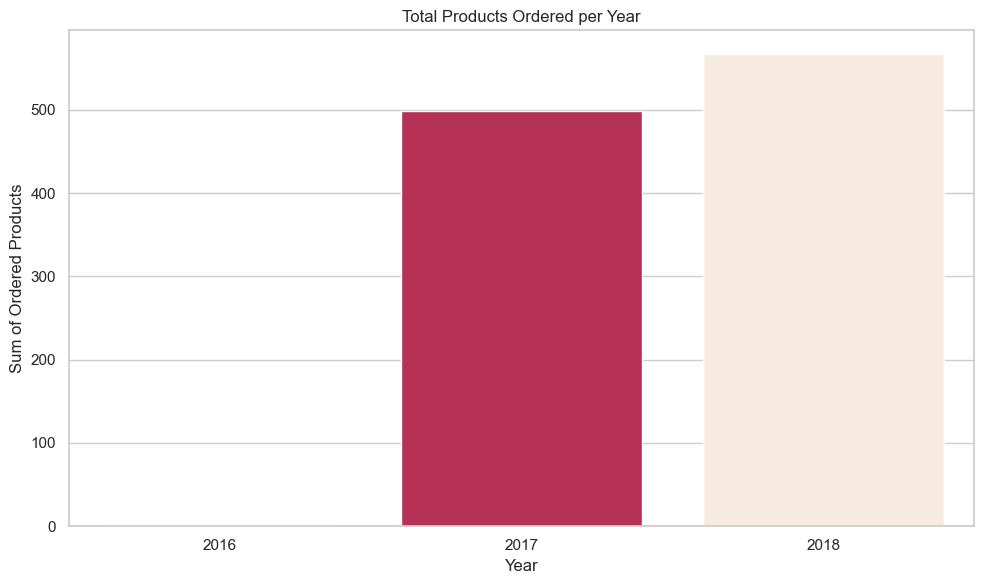

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(data=products_per_year_df, x="order_year", y="order_items_qty", hue="order_year", dodge=False, palette="rocket", legend=False)
plt.title("Total Products Ordered per Year")
plt.xlabel("Year")
plt.ylabel("Sum of Ordered Products")
plt.tight_layout()
plt.show()

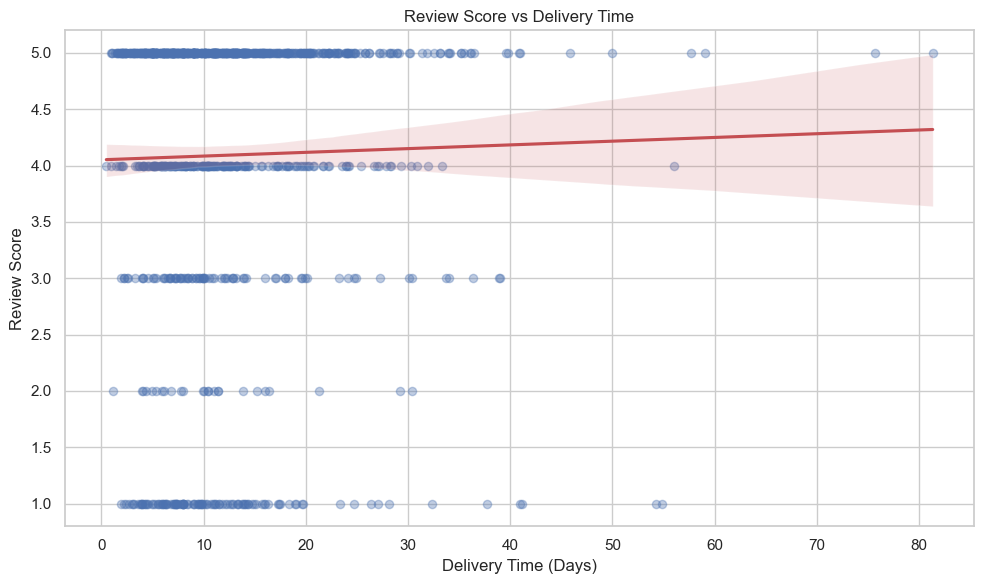

In [25]:
plot_df = cleaned_df.copy()
plot_df["review_score"] = pd.to_numeric(plot_df["review_score"], errors="coerce")
plot_df["delivery_time_days"] = pd.to_numeric(plot_df["delivery_time_days"], errors="coerce")
plot_df = plot_df.dropna(subset=["review_score", "delivery_time_days"])

plt.figure(figsize=(10, 6))
sns.regplot(data=plot_df, x="delivery_time_days", y="review_score", scatter_kws={"alpha": 0.35, "s": 35}, line_kws={"color": "#c44e52"})
plt.title("Review Score vs Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Review Score")
plt.tight_layout()
plt.show()

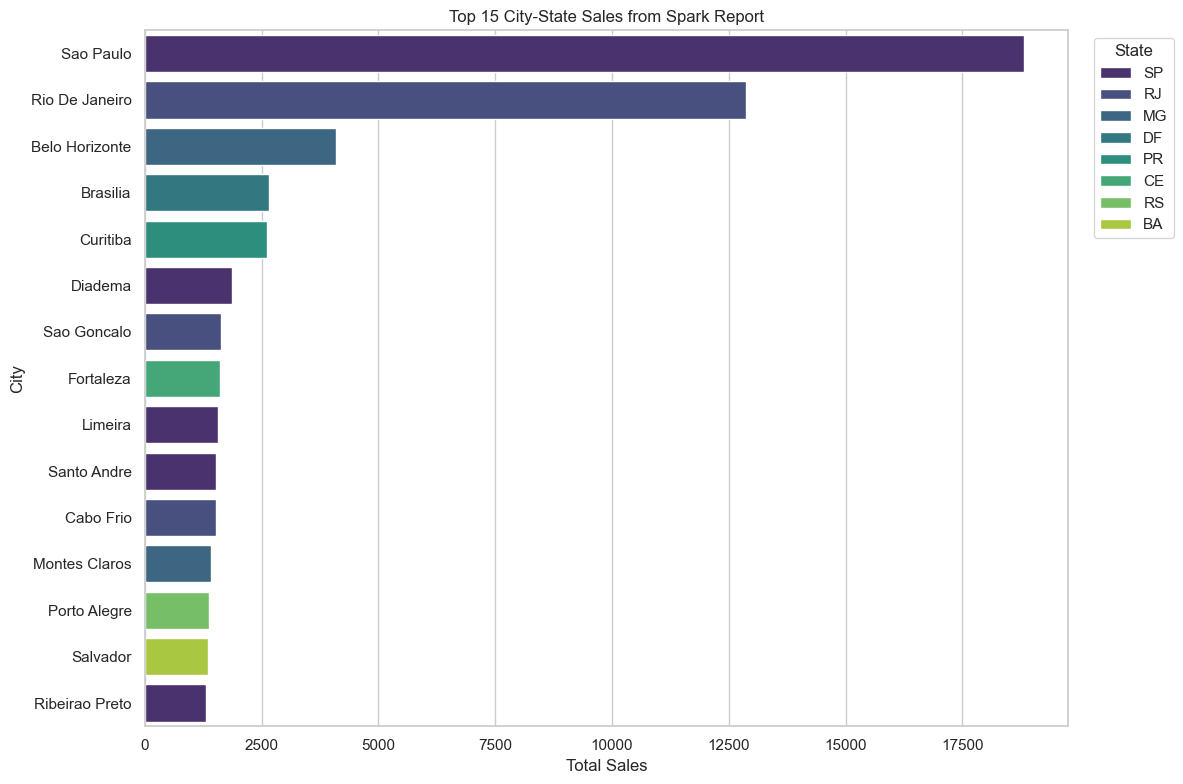

In [26]:
if not city_report_df.empty:
    top_city_report_df = city_report_df.sort_values("total_sales", ascending=False).head(15)
    plt.figure(figsize=(12, 8))
    sns.barplot(data=top_city_report_df, x="total_sales", y="customer_city", hue="customer_state", dodge=False, palette="viridis")
    plt.title("Top 15 City-State Sales from Spark Report")
    plt.xlabel("Total Sales")
    plt.ylabel("City")
    plt.legend(title="State", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No Spark city report found under output/sales_by_city_report/")